In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import torch as tn
import random
import warnings
import multiprocessing as mp
from functools import partial
from scipy.integrate import quad, IntegrationWarning
import time
from datetime import date, time, datetime
from concurrent.futures import ThreadPoolExecutor
from constants import *

# Import files
from rotation import*
#from functions import d_sigma, d_sigma_sm, sigma_sm, sme, sigma_full, summation_terms, integrate_sigma_hat_prime_sm, integrate_sigma_hat_prime_sme, dsigma_dQ, dsigma_dQ_1,dsigma_dQ_2,dsigma_dQ_3#, y_max_of_Q2, d2sigma_dQ2_dy_sm, d2sigma_dQ2_dy_liv, d2sigma_dQ2_dy_full, dsigma_dy_sm, dsigma_dy_liv, dsigma_dy_full
from math import sqrt

In [2]:
# Quarks
quarks = [
    (2, 2/3*e, 'u', 1/2),
     (1, -1/3*e, 'd', -1/2),
     (3, -1/3*e, 's', -1/2),
     # (4, 2/3*e, 'c', 1/2),
     #  (5, -1/3*e, 'b', -1/2),
     # (6, 2/3*e, 't', 1/2),
]

# List of quark properties and couplings
quark_couplings = []

for flavor, e_f, name, I3 in quarks:
    g_fR = -e_f * sin2th_w
    g_fL = I3 - e_f * sin2th_w
    
    # Rounding to 4 decimal places
    e_f = round(e_f, 10)
    g_fR = round(g_fR, 10)
    g_fL = round(g_fL, 10)
    
    quark_couplings.append((flavor, e_f, g_fR, g_fL))

print(quark_couplings)
quark_couplings1 = [(2, 0.2018666667, -0.046673592, 0.453326408)]
quark_couplings2 = [(1, -0.1009333333, 0.023336796, -0.476663204)]
#Don't foregt the metric convenction (+, -, -, -)
g = tn.tensor([
    [1,0,0,0],
    [0,-1,0,0],
    [0,0,-1,0],
    [0,0,0,-1]
], dtype=tn.float32)
CL1 = tn.tensor([
    [0, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, -1, 0],
    [0,0, 0, 0]
], dtype=tn.float32)
CL2 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, -1, 0],
    [0, -1, 0, 0],
    [0,0, 0, 0]
], dtype=tn.float32)
CL3 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, -1],
    [0, 0, 0, 0],
    [0,-1, 0, 0]
], dtype=tn.float32)
CL4 = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, -1],
    [0,0,-1, 0]
], dtype=tn.float32)

CLzz = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0,0,0, -1]
], dtype=tn.float32)

CR = tn.tensor([
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=tn.float32)


[(2, 0.2018666667, -0.046673592, 0.453326408), (1, -0.1009333333, 0.023336796, -0.476663204), (3, -0.1009333333, 0.023336796, -0.476663204)]


In [3]:
#rotation matrices

# Define the constant tensors once
p1 =  tn.tensor([1, 0, 0, 1], dtype=tn.float32)
p2 =  tn.tensor([1, 0, 0, -1], dtype=tn.float32)

# Precompute total number of steps

specific_time = datetime(2017, 1, 1, 0, 0)

start_time = int(specific_time.timestamp())

# start_time = int(time.time())
end_time = start_time + int(timedelta(days=1).total_seconds())
step_seconds = int(timedelta(hours=1).total_seconds())
num_steps = (end_time - start_time) // step_seconds

# Lists to store the times and contr matrix elements
times = []
contrelep1 = []
contrelep2 = []

R_y_lat = R_y(latitude)
R_z_azi = R_z(azimuth)
mat_cons = tn.matmul(R_y_lat,R_z_azi)
# Main loop
current_time = start_time
for _ in range(num_steps):
    # Convert current_time to a timestamp
    current_datetime = datetime.fromtimestamp(current_time)
    time_utc = current_datetime.timestamp()

    # Calculate omega_t
    omega_t_sid = omega_utc * time_utc + 3.2830 
    # Construct the complete rotation matrix from SCF to CMS
    R_Z_omega = R_Z(omega_t_sid)
    R_mat = tn.matmul(R_Z_omega, mat_cons)
    R_matrix1 = tn.einsum('ma,an->mn', g, R_mat)
    R_matrix2 = tn.einsum('am,na->mn', g, R_mat)
    # print(R_matrix1)
    # Compute contrL and contrR using matrix multiplication
    contrp1 = tn.einsum('ij,j->i', R_matrix1, p1)
    contrp2 =  tn.einsum('ij,i->j',R_matrix2, p2)
    # Record the times and contr matrix elements
    times.append(current_time)
    contrelep1.append(contrp1)
    contrelep2.append(contrp2)


    # Move to the next time step
    current_time += step_seconds
 

In [5]:
from test_functions import dsigma_y_sm
def calculate_sm(Q2, y, quark_couplings):
    return dsigma_y_sm(Q2, y, quark_couplings)
Q2 = 91.4 ** 2
ys = np.linspace(-7.0, 7.0, 31)

sm_dy = np.array([dsigma_y_sm(Q2, y, quark_couplings) for y in ys])


LHAPDF 6.5.4 loading /work/submit/bsu17/miniforge3/envs/liv-sme/share/LHAPDF/NNPDF31_nnlo_as_0118/NNPDF31_nnlo_as_0118_0000.dat
NNPDF31_nnlo_as_0118 PDF set, member #0, version 1; LHAPDF ID = 303600


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


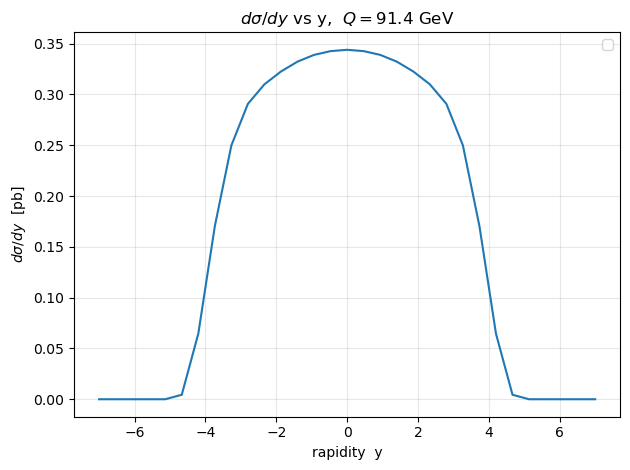

In [6]:
plt.plot(ys, sm_dy)
plt.xlabel('rapidity  y')
plt.ylabel(r'$d\sigma/dy$  [pb]')
plt.title(rf'$d\sigma/dy$ vs y,  $Q=91.4$ GeV')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'sigma_vs_rapidity_fixedQ_SM={np.sqrt(Q2)}.png', dpi=150)
plt.show()

In [7]:
from test_functions import dsigma_y_liv
def calculate_sm(Q2, y, quark_couplings):
    return dsigma_y_sm(Q2, y, quark_couplings)
Q2 = 91.4 ** 2
ys = np.linspace(-7.0, 7.0, 31)

up_right = np.array([dsigma_y_liv(Q2, y, CR, CL1, p1, p2, quark_couplings1) for y in ys])
up_left = np.array([dsigma_y_liv(Q2, y, CLzz, CR, p1, p2, quark_couplings1) for y in ys])
down_left = np.array([dsigma_y_liv(Q2, y, CLzz, CR, p1, p2, quark_couplings2) for y in ys])
down_right = np.array([dsigma_y_liv(Q2, y, CR, CLzz, p1, p2, quark_couplings2) for y in ys])


c_up = [up_right[i] + up_left[i] for i in range(len(up_left))]
d_up = [up_right[i] - up_left[i] for i in range(len(up_left))]
c_down = [down_right[i] + down_left[i] for i in range(len(up_left))]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


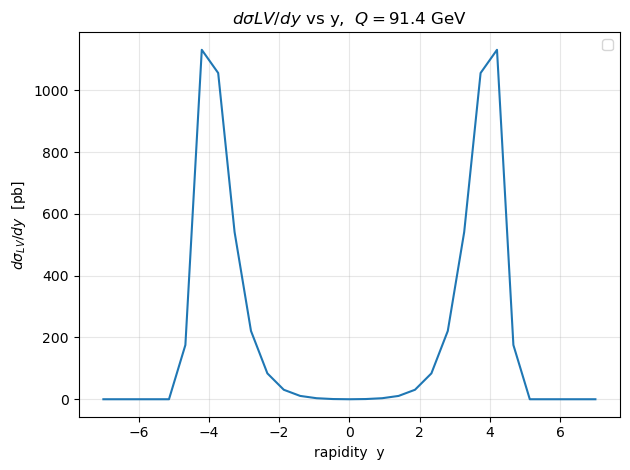

In [8]:
plt.plot(ys, c_up)
#plt.plot(ys, d_up)
#plt.plot(ys, c_down)
plt.xlabel('rapidity  y')
plt.ylabel(r'$d\sigma_{LV}/dy$  [pb]')
plt.title(r'$d\sigma{LV}/dy$ vs y,  $Q=91.4$ GeV')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'sigma_vs_rapidity_fixedQ={np.sqrt(Q2)}_LV.png', dpi=150)
plt.show()